# <span style="color:black; font-weight:bold;">Cross-modal alignment renal cell carcinoma-HE Tutorial</span>
+ <span style="color:black; font-weight:bold;">Creator</span>: Bingjie Dai (17516970902@163.com)
+ <span style="color:black; font-weight:bold;">Date of Creation</span>: 8.23.2026
+ <span style="color:black; font-weight:bold;">Date of Last Modification</span>: 8.23.2026
+ <span style="color:black; font-weight:bold;">Download</span>: Cross-modal renal cell carcinoma data used in the tutorial are available at [Xenium.h5ad](https://drive.google.com/file/d/1Tu_sDL08eRHHHY8NHw7tLfO7FnkfRIoH/view?usp=sharing), [kidney_multi-omics-HE.h5ad](https://drive.google.com/file/d/1_usDqnMNAF6TaH3pP9nPuaigc61peQZs/view?usp=sharing) and [Xenium_V1_Human_Kidney_FFPE_Protein_updated_he_image.ome.tif](https://drive.google.com/file/d/1-ZXrhKkzsDBaQ1J4y7oVXPPmN9khYEph/view?usp=sharing). 
In this tutorial we apply MAPS to align Xenium renal cell carcinoma to HE Breast cancer dataset

<span style="color:black; font-weight:bold;">The dataset have:</span>   
+ <span style="color:black; font-weight:bold;">Xenium(ST)</span>: 465,545 cells and 396 genes   
+ <span style="color:black; font-weight:bold;">HE(Cellpose-SAM)</span>: 449,030 cells 

In [1]:
from MAPS.align import Rigid_alignment
from MAPS.utils import set_seed,create_new_color_dict,plot_aligned_adata_on_if
import scanpy as sc
import pandas as pd
import torch
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
set_seed(7)

## <span style="color:black; font-weight:bold;">Loading renal cell carcinoma data (Xenium and HE)</span>
+ To ensure the accuracy of the scaling factor, we recommend using the slice with a larger initial coordinate range as the target_adata for learning the scaling factor.

In [4]:
source_adata=sc.read_h5ad('/home/dbj/LPcross/Data/HERNA/Xenium-multiomics/Xenium.h5ad')
source_adata.obs['batch']='Xenium'

target_adata=sc.read_h5ad('/home/dbj/LPcross/Data/HERNA/Xenium-multiomics/kidney_multi-omics-HE.h5ad')
target_adata.obs['batch']='HE'

## <span style="color:black; font-weight:bold;">Spatial mapping of the renal cell carcinoma before alignment</span>

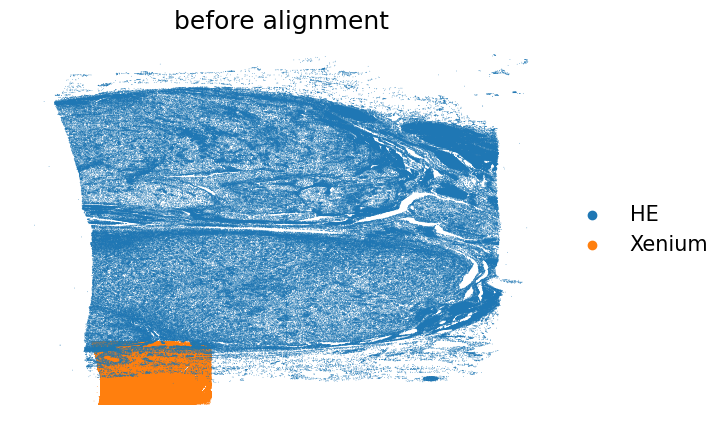

In [5]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (7,5)
plt.rcParams['font.size'] = 15

adata=sc.concat([source_adata,target_adata],join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color='batch',title='before alignment',size=1,frameon=False)

## <span style="color:black; font-weight:bold;">Align the slices using MAPS</span> 
### <span style="color:black; font-weight:bold;">Training parameters</span> 
+ epochs: Training ephchs  
+ device: Training device  
+ sample_size: The number of samples used for alignment  
+ enable_scale: Whether to learn the scaling factor?  

### <span style="color:black; font-weight:bold;">Output</span>   
+ aligned_spatial: The coordinates of the source slices after alignment  
+ theta_deg: Angle of rotation  
+ translation: Translation matrix  
+ scale: Scaling factor

In [6]:
%%time
source = source_adata.obsm['spatial'].astype(np.float32) 
target = target_adata.obsm['spatial'].astype(np.float32)  

aligned_spatial, theta_deg, translation,scale= Rigid_alignment(source, target, epochs=6000, sample_size=20000,enable_scale=True,device=device)
source_adata.obsm['spatial'] = aligned_spatial

Scanning angles to find best starting angle...


Global Align: 100%|████████████████████████████████| 6000/6000 [01:51<00:00, 53.61it/s, Loss=102.47, Scale=3.649, Rot=-0.19°, Trans=(6867.7, 28358.3)]


Peak GPU memory usage: 4.884 GB
Scale factor: 3.648, Rotation angle: -0.13°, Translation (x, y): (6868.32, 28357.37)
CPU times: user 1min 22s, sys: 31.9 s, total: 1min 54s
Wall time: 1min 54s


## <span style="color:black; font-weight:bold;">Spatial mapping of the renal cell carcinoma after alignment</span>

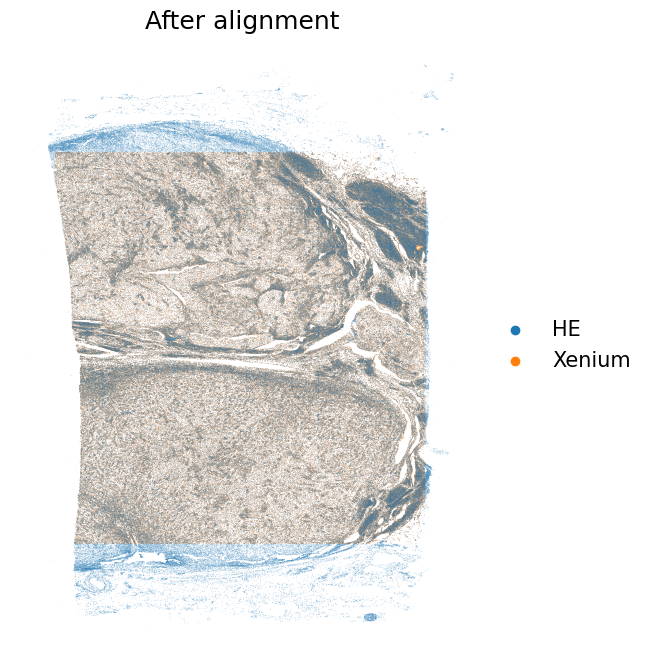

In [10]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (6,8)
plt.rcParams['font.size'] = 15

adata=sc.concat([source_adata,target_adata],join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color='batch',title='After alignment',size=0.4,alpha=0.7,frameon=False)

## <span style="color:black; font-weight:bold;">Spatial co-localization of cell and HE</span>

(<Figure size 1050x1200 with 1 Axes>, <Axes: >)

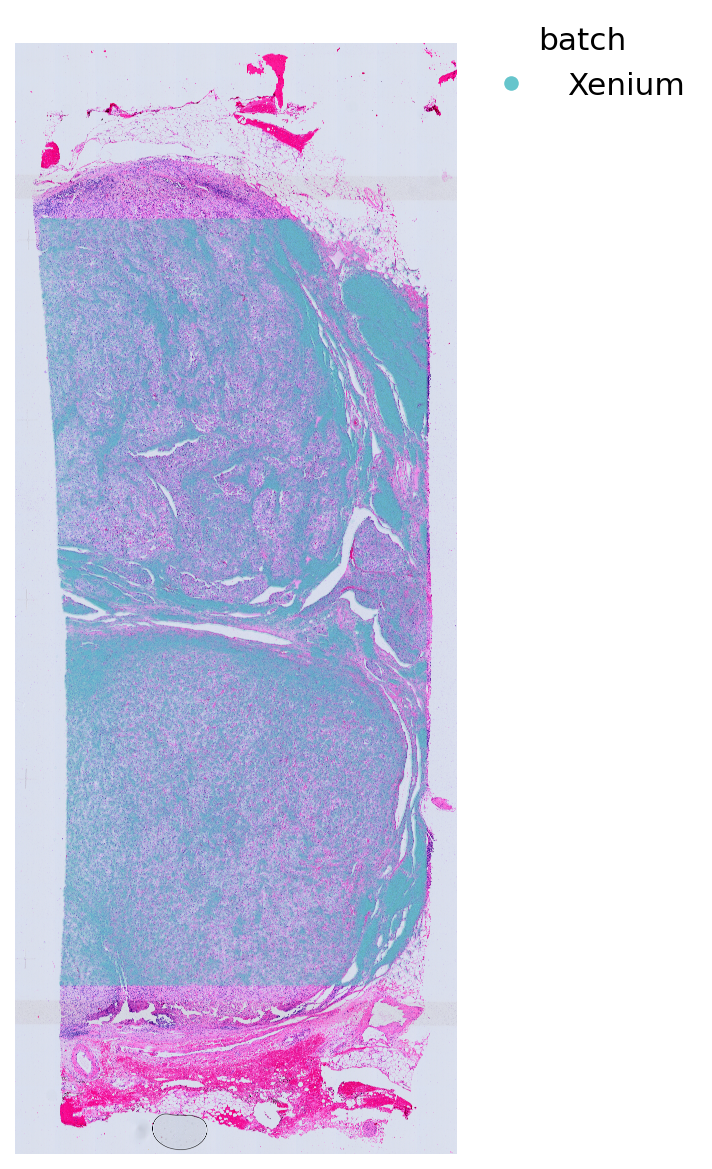

In [17]:
img_path = '/home/dbj/LPcross/Data/HERNA/Xenium-multiomics/Xenium_V1_Human_Kidney_FFPE_Protein_updated_he_image.ome.tif'
color_dict=create_new_color_dict(source_adata,cat_key='batch')

plot_aligned_adata_on_if(image_path=img_path, 
                         adata=source_adata,
                         color_by='batch',
                         is_gene=False,
                         s=0.005,
                         palette=color_dict,
                         figsize=(7,8),
                         dpi=150,
                         #save_path='/home/dbj/LPcross/Data/result/HE/breast_cancer/clusterHEDPI600test.png'
                        )